# Process 1 — event log split into material flow + machine activities, and the energy curves of one activity

Rebuilds the two blocks of the paper figure, straight from the simulated process-1 event log
and one pipeline run:

1. **Material-flow layer** — the station-to-station route of a batch (`Water_supply → Destillation →
   Bottling → autoclaving_{1,2,3} → Individual_packaging → Warehousing`), autoclaving split into its
   parallel machines.
2. **Machine-activity layer** — the internal activities of ONE machine (`FOCUS_OBJECT`, default
   `autoclaving_3`): `prepare → heat → hold → cool`.
3. **Energy curves per machine activity** — every occurrence of that activity in the chosen case set,
   plotted against its own real elapsed time (no resampling, no barycenter).

The case set is the **test split of the pipeline run** (`RUN`), read from that run's own
`predicted_logs/<process>_test_set.parquet`, so the split is identical to the one the run evaluated on.

**Real vs simulated curves** — only `CURVE_SOURCE` changes:

| `CURVE_SOURCE`   | curves                                                                 |
|------------------|------------------------------------------------------------------------|
| `real_expanded`  | real sensor readings from the gold `df_expanded` (what this run shows)  |
| `run_real`       | `real` series of the run's saved curve file — cross-check of the above  |
| `run_predicted`  | `predicted` series of one approach — the **simulated** test curves      |

`run_*` needs a run with saved curves (`save_predicted_curves: True` in `01_pipeline.py`). Check which
runs under `results/` have `complete_curve_eval_results/<process>/<mode>/predicted_curves*.parquet`
and point `RUN` / `SIM_MODE` / `SIM_APPROACH` at one of them (section 8 below lists what the current
run has to offer).

Sections 1–7 build the single figure for the **real** version. Section 9 rebuilds the exact same
figure for the **simulated** version (predicted curves) using the config set in section 8 — it
doesn't just change the variables, it re-derives everything downstream of them (`run_dir`, the test
split, both nets, the curves, the panels) so the simulated process model and profiles actually
render instead of silently reusing the real run's data. The notebook produces exactly **two images**:
the real paper figure and the simulated one.


In [1]:
# ── Config ───────────────────────────────────────────────────────────────────
RUN             = 'experiment_1000'   # dir under ../results: full name or any substring (latest match)
DATA_EXPERIMENT = '1'                # gold data experiment that run was fed with
PROCESS         = 'process_1'
SPLIT           = 'test'             # 'test' | 'train' | 'all'  — which cases the curves come from
FOCUS_OBJECT    = 'autoclaving_2'    # the machine the machine-activity layer zooms into

# Curve panels given as (phase, sensor).  The activity name is built as
# f'{FOCUS_OBJECT}_{phase}', so only the PHASE is spelled here.  Writing the whole activity by
# hand is how you end up asking for 'autoclaving_1' instead of 'autoclaving_1_heat' -- that
# matches no activity, yields 0 curves, and the panel is silently dropped.
# Set PANEL_PHASES = None to auto-pick the dominant sensor of every FOCUS_OBJECT activity.
# Set a phase's sensor to 'autoclave_temperature_C' to show the vessel temperature instead of a
# demand channel -- it is NOT a recorded sensor but the physical autoclave model re-solved at that
# occurrence's own duration and volume (see cell 4).
PANEL_PHASES = [
    ('heat', 'autoclave_steam_demand_kW_energy_to_model'),
    ('hold', 'autoclave_steam_demand_kW_energy_to_model'),
    ('cool', 'autoclave_cooling_water_demand_kW_energy_to_model'),
]
PANELS = None if PANEL_PHASES is None else [(f'{FOCUS_OBJECT}_{ph}', s) for ph, s in PANEL_PHASES]

# ── Where the curves come from ───────────────────────────────────────────────
CURVE_SOURCE = 'real_expanded'   # 'real_expanded' | 'run_real' | 'run_predicted'

# Only used by 'run_real' / 'run_predicted':
SIM_SCOPE    = 'complete'        # 'complete' → complete_curve_eval_results/<process>/<SIM_MODE>/
                                 # 'schedule' → schedule_profile_eval_results/<process>/
SIM_MODE     = 'petri_net_budget_ml_plus_per_act'      # net + duration-model directory
                                 # best mode for process_1 by the run's own test_overall_error
                                 # (0.1136 vs 0.1182 for petri_net_heuristic_ml_plus_per_act)
SIM_APPROACH = 'ml_step_dtw_smooth'        # curve approach; '' → predicted_curves.parquet
                                 # NB approaches are per-run: 976 saved exemplar /
                                 # median_activity_sensor / ml_external / ml_rawspace,
                                 # 988 saved ml_step_dtw only (same test split either way)
SIM_SERIES   = None              # None → 'real' for run_real, 'predicted' for run_predicted.
                                 # 'schedule' scope also has: schedule, stochastic, bootstrap,
                                 # best, best_duration_corrected, best_budget
SIM_LOG      = 'auto'            # which log gives the activity windows:
                                 # 'auto' → real test log for real/schedule/stochastic/bootstrap,
                                 #          predicted_logs/<process>_<SIM_MODE>.parquet otherwise
                                 # 'real' | 'sim' to force it

# ── Plotting ─────────────────────────────────────────────────────────────────
MAX_CURVES   = 60                # occurrences drawn per panel (None = all)
NET_DPI      = 200               # graphviz render resolution for the two nets
NET_MARGIN   = 0.1               # graphviz page margin, inches (used to place the arrows)
OUT_DIR      = 'visuals/process_and_profiles'
SAVE         = True    # save the FINAL combined figure
SAVE_NETS    = False   # write the raw graphviz nets as separate PDFs
SHOW_INTERMEDIATE = False   # draw the net previews + the two standalone figures

In [2]:
import ast
import re
import sys
import tempfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
from IPython.display import Image, display

import pm4py
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.visualization.heuristics_net import visualizer as hn_vis

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 130,
})

REPO    = next(d for d in [Path.cwd(), *Path.cwd().parents]
               if (d / 'results').is_dir() and (d / 'data').is_dir())   # repo root, from anywhere
RESULTS = REPO / 'results'
GOLD    = REPO / 'data' / 'gold' / f'experiment_{DATA_EXPERIMENT}' / PROCESS / 'datasets'
OUT     = Path(OUT_DIR)
if SAVE:
    OUT.mkdir(parents=True, exist_ok=True)

_matches = [d for d in sorted(RESULTS.iterdir()) if d.is_dir() and (d.name == RUN or RUN in d.name)]
assert _matches, f'no run under {RESULTS} matching {RUN!r}'
run_dir = _matches[-1]

df_event_log = pd.read_parquet(GOLD / 'df_event_log.parquet')
df_expanded  = pd.read_parquet(GOLD / 'df_expanded.parquet')

SENSOR_COLS = [c for c in df_expanded.columns if c.endswith('_energy_to_model')]

print(f'run   : {run_dir.name}' + ('' if RUN == run_dir.name else f'   (latest match for {RUN!r})'))
print(f'gold  : {GOLD.relative_to(REPO)}')
print(f'log   : {len(df_event_log)} events, {df_event_log["case_id"].nunique()} cases, '
      f'{df_event_log["activity"].nunique()} activities')
print(f'energy: {len(df_expanded)} rows, {len(SENSOR_COLS)} sensors')

run   : experiment_1000_20260729_201444   (latest match for 'experiment_1000')
gold  : data/gold/experiment_1/process_1/datasets
log   : 5621 events, 300 cases, 25 activities
energy: 36382 rows, 6 sensors


## 1. Case set — the run's own test split

Taken from `predicted_logs/<process>_test_set.parquet` when the run wrote one (exact same split the run
evaluated on); otherwise re-derived as the temporal split at the ratio printed in that run's
`pipeline_execution.log`.


In [3]:
_all_cases  = set(df_event_log['case_id'].dropna().unique())
_test_path  = run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet'

if _test_path.exists():
    test_cases  = set(pd.read_parquet(_test_path)['case_id'].dropna().unique())
    split_source = f'predicted_logs/{PROCESS}_test_set.parquet'
else:
    _log = (run_dir / 'pipeline_execution.log')
    _m = re.search(r'SPLIT \((\d+)% train', _log.read_text()) if _log.exists() else None
    _ratio = int(_m.group(1)) / 100 if _m else 0.80
    _case_start = df_event_log.groupby('case_id')['timestamp_start'].min().sort_values()
    _n_train = max(1, int(len(_case_start) * _ratio))
    test_cases = set(_case_start.index[_n_train:])
    split_source = f'temporal split re-derived at train_ratio={_ratio:.2f} (run saved no test set)'

train_cases = _all_cases - test_cases
cases = {'test': test_cases, 'train': train_cases, 'all': _all_cases}[SPLIT]

print(f'split source : {split_source}')
print(f'train / test : {len(train_cases)} / {len(test_cases)} cases')
print(f'SPLIT={SPLIT!r} → {len(cases)} cases used below')


split source : predicted_logs/process_1_test_set.parquet
train / test : 210 / 90 cases
SPLIT='test' → 90 cases used below


## 2. Split the event log into the two layers

* **material flow** — one node per station, but the station `FOCUS_OBJECT` belongs to (`Autoclaving`) is
  broken up into its machines, so the parallel branches show up. Consecutive repeats of the same node are
  collapsed, so the edges are the station-to-station handovers of a batch.
* **machine activities** — every event of `FOCUS_OBJECT` only, at activity level.


In [4]:
el = (df_event_log[df_event_log['case_id'].isin(cases)]
      .sort_values(['case_id', 'timestamp_start'])
      .copy())

_focus_rows = el[el['object'] == FOCUS_OBJECT]
assert len(_focus_rows), f'{FOCUS_OBJECT!r} does not appear in this case set'
MACHINE_STATION = _focus_rows['station'].iloc[0]

# ── material-flow layer ──────────────────────────────────────────────────────
df_material = el.copy()
df_material['flow_node'] = np.where(df_material['station'] == MACHINE_STATION,
                                    df_material['object'], df_material['station'])
_prev = df_material.groupby('case_id')['flow_node'].shift(1)
df_material = df_material[df_material['flow_node'] != _prev].copy()

# ── machine-activity layer ───────────────────────────────────────────────────
df_machine = el[el['object'] == FOCUS_OBJECT].copy()

# activities of the focus machine, in process order (mean position within its own trace)
_order = (df_machine.assign(pos=df_machine.groupby('case_id').cumcount())
          .groupby('activity')['pos'].mean().sort_values())
MACHINE_ACTIVITIES = list(_order.index)

print(f'material flow  : {len(df_material)} handovers, nodes = '
      f'{list(df_material["flow_node"].value_counts().index)}')
print(f'machine layer  : {len(df_machine)} events on {FOCUS_OBJECT} '
      f'({df_machine["case_id"].nunique()} cases)')
print(f'  activities in process order: {MACHINE_ACTIVITIES}')
display(df_machine.groupby('activity').size().rename('events').to_frame().T)


material flow  : 635 handovers, nodes = ['Warehousing', 'Individual_packaging', 'Water_supply', 'Destillation', 'Bottling', 'autoclaving_2', 'autoclaving_3', 'autoclaving_1']
machine layer  : 184 events on autoclaving_2 (40 cases)
  activities in process order: ['autoclaving_2_prepare', 'autoclaving_2_heat', 'autoclaving_2_hold', 'autoclaving_2_cool']


activity,autoclaving_2_cool,autoclaving_2_heat,autoclaving_2_hold,autoclaving_2_prepare
events,46,46,46,46


## 3a. Material-flow net


In [5]:
def load_net_image(png):
    """Read a graphviz PNG and flatten it onto white -- its page margin is transparent,
    which otherwise shows up as a faint rectangle around the net."""
    im = mpimg.imread(png)
    if im.ndim == 3 and im.shape[2] == 4:
        rgb, alpha = im[..., :3], im[..., 3:4]
        im = rgb * alpha + (1.0 - alpha)
    return im


def _to_pm4py(df, activity_col):
    d = df.rename(columns={'case_id': 'case:concept:name',
                           activity_col: 'concept:name',
                           'timestamp_start': 'time:timestamp'})
    d = d[['case:concept:name', 'concept:name', 'time:timestamp']].copy()
    d['time:timestamp'] = pd.to_datetime(d['time:timestamp'])
    return pm4py.convert_to_event_log(d)


def heuristic_net(df, activity_col, pdf_name=None, **heu_kwargs):
    """Mine + render a heuristics net.  Returns (png_path, gviz) — the graphviz object is
    kept so cell 7b can read the node coordinates back out of it."""
    log = _to_pm4py(df, activity_col)
    net = heuristics_miner.apply_heu(log, parameters=heu_kwargs or None)
    gviz = hn_vis.apply(net)
    try:                                  # sharper rendering + a known margin
        gviz.graph_attr['dpi'] = str(NET_DPI)
        gviz.graph_attr['margin'] = str(NET_MARGIN)
    except Exception:
        pass
    png = tempfile.NamedTemporaryFile(suffix='.png', delete=False).name
    hn_vis.save(gviz, png)
    if SAVE_NETS and pdf_name:
        # hn_vis.save() writes PNG bytes whatever the extension -- render vector via graphviz
        gviz.render(str(OUT / Path(pdf_name).stem), format='pdf', cleanup=True)
        print(f'saved {OUT / pdf_name}')
    return png, gviz


png_material, gviz_material = heuristic_net(df_material, 'flow_node',
                                            f'net_material_flow_{PROCESS}_{SPLIT}.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_material))


# ── Pinned layout: draw the simulated net where the real one put its nodes ────
# The two nets are mined from different logs, so pm4py hands graphviz the same
# activities in a different order and dot's crossing minimiser lands on a different
# left-to-right arrangement -- the halves then LOOK like different processes when the
# discovered structure is identical (same nodes, same edges; only the frequencies on
# them differ). Laying the second net out at the first one's coordinates removes that
# false signal: anything that still looks different between the halves IS different.
import graphviz, re

# pm4py quotes the uuid node ids but writes the start/end markers bare (`start_0 [...]`),
# and -n2 fails outright if ANY node lacks a position -- so both forms must match.
_NODE_LINE = re.compile(r'^\s*(?P<id>"[^"]+"|[A-Za-z_]\w*)\s*\[(?P<attrs>.*)\]\s*$')


class _PinnedGraph:
    """A graphviz graph whose layout is fixed: every pipe() goes through neato -n2.

    Needed because pinning is a RENDER-time flag, not a graph attribute. Without it
    neato treats `pos` as a starting hint and relaxes the layout anyway, and
    net_node_positions() -- which pipes 'plain' to place the arrows -- would report
    coordinates the picture does not use."""

    def __init__(self, graph):
        self._g = graph
        self.graph_attr = graph.graph_attr

    def pipe(self, *args, **kwargs):
        kwargs.setdefault('neato_no_op', 2)
        return self._g.pipe(*args, **kwargs)


def _plain_positions(gviz):
    """label (without its ' (count)' suffix) -> (x, y) in graphviz inches."""
    txt = gviz.pipe(format='plain').decode('utf-8', 'replace')
    out = {}
    for line in txt.splitlines():
        try:
            parts = shlex.split(line)
        except ValueError:
            continue
        if parts and parts[0] == 'node' and len(parts) >= 7:
            out[parts[6].split(' (')[0]] = (float(parts[2]), float(parts[3]))
    return out


def pin_net_like(png, gviz, reference_gviz, pdf_name=None):
    """Re-render `gviz` with every node fixed where `reference_gviz` placed it.

    Node identity is the label minus its frequency suffix, since the counts differ
    between the two logs. neato with pos+pin keeps the nodes and routes the edges
    around them. Returns (png, gviz) like heuristic_net; if the reference has no
    position for some node -- a genuinely different net -- nothing is pinned and the
    net keeps its own layout, because forcing a partial one would be a lie."""
    try:
        pos = _plain_positions(reference_gviz)
    except Exception as exc:
        print(f'! reference layout unavailable ({exc}) — simulated net keeps its own')
        return png, gviz

    g = graphviz.Digraph(engine='neato', strict=True)
    g.graph_attr.update(gviz.graph_attr)
    g.graph_attr.update(splines='true', overlap='true')
    missing = []
    for line in gviz.body:
        m = _NODE_LINE.match(line)
        if m and '->' not in line:
            lab = re.search(r'label="([^"]*)"', m.group('attrs'))
            key = lab.group(1).split(' (')[0] if lab else None
            if key not in pos:
                missing.append(key)
            else:
                x, y = pos[key]
                line = f'{line.rstrip()[:-1]} pos="{x * 72:.2f},{y * 72:.2f}" pin=true]'
        g.body.append(line)
    if missing:
        print(f'! not in the reference net: {missing} — simulated net keeps its own layout')
        return png, gviz

    pinned = _PinnedGraph(g)
    out_png = tempfile.NamedTemporaryFile(suffix='.png', delete=False).name
    with open(out_png, 'wb') as fh:
        fh.write(pinned.pipe(format='png'))
    if SAVE_NETS and pdf_name:
        with open(OUT / Path(pdf_name).with_suffix('.pdf').name, 'wb') as fh:
            fh.write(pinned.pipe(format='pdf'))
        print(f'saved {OUT / pdf_name} (pinned to the real net)')
    return out_png, pinned


## 3b. Machine-activity net (`FOCUS_OBJECT`)


In [6]:
png_machine, gviz_machine = heuristic_net(df_machine, 'activity',
                                          f'net_machine_{FOCUS_OBJECT}_{SPLIT}.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_machine))


## 4. Curve extraction

One curve per **occurrence** of an activity (not per case — a machine can run several cycles for the same
batch), taken from whichever source `CURVE_SOURCE` selects:

* `real_expanded` — rows of `df_expanded` labelled with that activity, grouped by
  `(case_id_log, timestamp_start_log)`, i.e. one group per event-log occurrence.
* `run_real` / `run_predicted` — the run's `predicted_curves*.parquet` (`case_id, sensor, series,
  t_minutes, value`, minutes since that curve's own case start), sliced by the activity windows of the
  matching log: the real test log for the real/schedule-driven series, the approach's own
  `predicted_logs/<process>_<SIM_MODE>.parquet` for the simulated series (its curves follow its own
  simulated schedule).


In [7]:
# Tolerance when slicing a run curve by an activity window, minutes.  Keep it at 0: back-to-back
# activities are only seconds apart, so any slack pulls the NEXT activity's first sample into the
# curve -- e.g. a hold curve flat at 22 kW ending on one 4007 kW sample of the following heat.
_EPS_MIN = 0.0
_curve_cache = {}


def curves_real_expanded(activity, sensor):
    """Returns a list of (t_minutes, value) pairs, t_minutes elapsed since the occurrence started."""
    sub = df_expanded[(df_expanded['activity_log'] == activity)
                      & (df_expanded['case_id_log'].isin(cases))].sort_values('datetime_energy')
    out = []
    for _, g in sub.groupby(['case_id_log', 'timestamp_start_log'], sort=True):
        v = g[sensor].to_numpy(dtype=float)
        t = (g['datetime_energy'] - g['datetime_energy'].iloc[0]).dt.total_seconds().to_numpy() / 60
        mask = np.isfinite(v)
        v, t = v[mask], t[mask]
        if len(v) > 2:
            out.append((t, v))
    return out


def _run_curve_path():
    if SIM_SCOPE == 'complete':
        d = run_dir / 'complete_curve_eval_results' / PROCESS / SIM_MODE
    else:
        d = run_dir / 'schedule_profile_eval_results' / PROCESS
    if not d.exists():
        _runs_with_curves = sorted({p.relative_to(RESULTS).parts[0]
                                    for p in RESULTS.glob('*/**/predicted_curves*.parquet')})
        raise AssertionError(f'{d} does not exist — this run saved no curves for that scope/mode.\n'
                             f'Runs that did: {_runs_with_curves}')
    for name in ([f'predicted_curves_{SIM_APPROACH}.parquet'] if SIM_APPROACH else []) + ['predicted_curves.parquet']:
        if (d / name).exists():
            return d / name
    raise AssertionError(f'no predicted_curves file for SIM_APPROACH={SIM_APPROACH!r} in {d}.\n'
                         f'available: {sorted(p.name for p in d.glob("predicted_curves*.parquet"))}')


def _run_curves_df():
    if 'curves' not in _curve_cache:
        p = _run_curve_path()
        _curve_cache['curves'] = pd.read_parquet(p)
        print(f'curves from {p.relative_to(run_dir)}  '
              f'| series: {sorted(_curve_cache["curves"]["series"].unique())}')
    return _curve_cache['curves']


def _window_log(series):
    use_real = (SIM_LOG == 'real') or (SIM_LOG == 'auto' and
                                       series in ('real', 'schedule', 'stochastic', 'bootstrap'))
    p = (run_dir / 'predicted_logs' /
         (f'{PROCESS}_test_set.parquet' if use_real else f'{PROCESS}_{SIM_MODE}.parquet'))
    assert p.exists(), f'{p} missing — cannot place activity windows for series {series!r}'
    key = ('log', p.name)
    if key not in _curve_cache:
        log = pd.read_parquet(p)
        log['timestamp_start'] = pd.to_datetime(log['timestamp_start'])
        log['timestamp_end']   = pd.to_datetime(log['timestamp_end'])
        _curve_cache[key] = log
        print(f'windows from predicted_logs/{p.name}')
    return _curve_cache[key]


def curves_from_run(activity, sensor, series):
    """Returns a list of (t_minutes, value) pairs, t_minutes elapsed since the activity started."""
    dfc = _run_curves_df()
    assert series in set(dfc['series']), \
        f'series {series!r} not in file (have {sorted(dfc["series"].unique())})'
    dfc = dfc[(dfc['sensor'] == sensor) & (dfc['series'] == series)]
    if dfc.empty:
        return []
    by_case = {c: g.sort_values('t_minutes') for c, g in dfc.groupby('case_id')}

    log = _window_log(series)
    log = log[log['case_id'].isin(cases)]
    case_t0 = log.groupby('case_id')['timestamp_start'].min()

    out = []
    occ = log[log['activity'] == activity].sort_values(['case_id', 'timestamp_start'])
    for _, r in occ.iterrows():
        g = by_case.get(r['case_id'])
        if g is None:
            continue
        t0 = case_t0[r['case_id']]
        a = (r['timestamp_start'] - t0).total_seconds() / 60
        b = (r['timestamp_end']   - t0).total_seconds() / 60
        sel = g.loc[g['t_minutes'].between(a - _EPS_MIN, b + _EPS_MIN)]
        v = sel['value'].to_numpy(dtype=float)
        t = sel['t_minutes'].to_numpy(dtype=float) - a
        mask = np.isfinite(v)
        v, t = v[mask], t[mask]
        if len(v) > 2:
            out.append((t, v))
    return out


# ── Vessel temperature — RECONSTRUCTED, not a recorded sensor ────────────────
# There is no temperature channel in this data.  The gold df_expanded and the run's curve files
# carry demand channels only (autoclave steam / cooling water, distillation steam / cooling,
# bottling, packaging, water supply) plus the exogenous weather columns ef_temperature_2m /
# ef_relative_humidity_2m -- and that ef_ temperature is outside air, not the vessel.
# The simulator DOES solve the vessel temperature: autoclave_function.sterilization_profile
# returns a 'temp' column, but generate_process_1.build_expanded writes only its Q, so the
# temperature was never persisted.  Replaying the generator to recover it does not work either --
# the current code no longer reproduces the gold log (different event structure and autoclave
# durations), so the RNG stream behind the recorded curves cannot be replayed.
#
# What happens instead: the SAME physical model is re-solved per occurrence, driven by that
# occurrence's own recorded numbers -- the cycle's total heat+hold+cool duration and its volume_L
# (which scales the thermal mass exactly as in the generator), at the ambient the generator solves
# the physics at.  Every other parameter stays at the generator's default, so no per-cycle
# randomisation is invented.  The reconstruction is faithful in the way that matters here: the
# model's own phase split reproduces the recorded phase durations (recorded heat 12.4 min ->
# reconstructed 12.4 min, etc.), so each curve spans the real occurrence's time.
# It is still a model output rather than a measurement, and the panel title says so.
TEMP_SENSOR = 'autoclave_temperature_C'

_STERI_PARAMS = ('m_dot_steam', 'm_dot_cool', 'A_U', 'T_steri', 'T_final', 'm_cp')


def _volume_of(attrs):
    """volume_L out of object_attributes — a dict in some logs, its repr in others."""
    if isinstance(attrs, str):
        attrs = ast.literal_eval(attrs)
    return float(attrs['volume_L'])


def _autoclave_cycles(log, machine):
    """The heat/hold/cool rows of each cycle `machine` ran, one DataFrame per cycle.

    The gold log labels cycles itself (autoclave_cycle_id); the simulated logs do not, so there a
    cycle is started by every 'heat' event of that machine within a case."""
    obj_col = 'resource_id' if 'resource_id' in log.columns else 'object'
    sub = log[(log[obj_col] == machine)
              & log['activity'].str.endswith(('_heat', '_hold', '_cool'))].copy()
    sub = sub[sub['case_id'].isin(cases)].sort_values(['case_id', 'timestamp_start'])
    if sub.empty:
        return []
    if 'autoclave_cycle_id' in sub.columns and sub['autoclave_cycle_id'].notna().all():
        keys = ['autoclave_cycle_id']
    else:
        sub['_cycle'] = sub.groupby('case_id')['activity'].transform(
            lambda s: s.str.endswith('_heat').cumsum())
        keys = ['case_id', '_cycle']
    return [g.sort_values('timestamp_start') for _, g in sub.groupby(keys, sort=True)]


def curves_temperature(activity):
    """Reconstructed vessel temperature (minutes, °C) for every occurrence of `activity`."""
    # imported here, not at cell level: the notebook must not need the simulator (or CoolProp)
    # unless a panel actually asks for the temperature.
    sys.path.insert(0, str(REPO / 'src' / 'simulation_process'))
    from autoclave_function import sterilization_profile
    import generate_process_1 as _gen

    machine, phase = activity.rsplit('_', 1)
    if CURVE_SOURCE == 'real_expanded':
        log = df_event_log                     # gold log — carries autoclave_cycle_id
    else:
        log = _window_log(SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted'))

    out = []
    for g in _autoclave_cycles(log, machine):
        if not g['activity'].str.endswith(f'_{phase}').any():
            continue
        t_ges = (g['timestamp_end'].max() - g['timestamp_start'].min()).total_seconds()
        if t_ges <= 0:
            continue
        p = dict(_gen.AUTOCLAVE_PARAM_DEFAULTS)
        p['m_cp'] *= _gen._load_factor(_volume_of(g['object_attributes'].iloc[0]))
        p['T_final'] = min(p['T_final'], p['T_steri'] - 20.0)      # stay physically valid
        prof = sterilization_profile(
            t_ges=int(round(t_ges)),
            T_amb=_gen.physics_ambient_c(g['timestamp_start'].min()) + 273.15,
            visual=False, **{k: p[k] for k in _STERI_PARAMS})
        seg = prof[prof['type'] == phase]
        if len(seg) > 2:
            t = (seg['time'].to_numpy(dtype=float) - float(seg['time'].iloc[0])) / 60
            out.append((t, seg['temp'].to_numpy(dtype=float)))
    return out


def panel_meta(sensor):
    """(y-axis label, panel title) for a sensor — the temperature panel is not in kW."""
    if sensor == TEMP_SENSOR:
        return '°C (reconstructed)', 'autoclave temperature'
    return 'kW', sensor.replace('_energy_to_model', '').replace('_energy', '')


def get_curves(activity, sensor):
    if sensor == TEMP_SENSOR:
        return curves_temperature(activity)
    if CURVE_SOURCE == 'real_expanded':
        return curves_real_expanded(activity, sensor)
    series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    return curves_from_run(activity, sensor, series)


# label that ends up in titles and file names
if CURVE_SOURCE == 'real_expanded':
    SOURCE_TAG, SOURCE_LABEL = 'real', 'real (gold expanded)'
else:
    _series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    SOURCE_TAG   = f'{_series}_{SIM_MODE}' + (f'_{SIM_APPROACH}' if SIM_APPROACH else '')
    SOURCE_LABEL = f'{_series} — {SIM_MODE}' + (f' / {SIM_APPROACH}' if SIM_APPROACH else '')
print(f'CURVE_SOURCE={CURVE_SOURCE!r} → {SOURCE_LABEL}')

CURVE_SOURCE='real_expanded' → real (gold expanded)


## 5. Panels — which (activity, sensor) pairs to draw

With `PANELS = None` each activity of the focus machine gets the sensor whose peak is highest during that
activity, and activities whose curves are flat/zero are dropped.


In [8]:
def dominant_sensor(activity):
    sub = df_expanded[(df_expanded['activity_log'] == activity)
                      & (df_expanded['case_id_log'].isin(cases))]
    if sub.empty:
        return None
    peaks = {c: float(sub[c].max()) for c in SENSOR_COLS}
    best = max(peaks, key=peaks.get)
    return best if peaks[best] > 0 else None


if PANELS is None:
    panels = [(a, s) for a in MACHINE_ACTIVITIES if (s := dominant_sensor(a))]
else:
    panels = list(PANELS)

for a, s in panels:
    print(f'  {a:<28} {s}')

_bad = [a for a, _ in panels if a not in MACHINE_ACTIVITIES]
if _bad:
    print(f'!! these panels name activities {FOCUS_OBJECT} does not have: {_bad}'
          f'\n   available: {MACHINE_ACTIVITIES}')


  autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model


## 6. Curve data per panel

Extracted here, plotted only in the paper figure below (section 7) — no separate per-panel plot, no
barycenter/average, each occurrence keeps its own real elapsed time.


In [9]:
def draw_panel(ax, activity, sensor, curves, n_total, fs=1.0, ylabel='kW', title=None):
    """One profile panel.  The y unit and the title come from panel_meta(sensor)."""
    for t, v in curves:
        ax.plot(t, v, color='blue', alpha=0.15, lw=0.9)
    ax.set_title(title if title is not None else panel_meta(sensor)[1], fontsize=13 * fs)
    ax.set_xlabel('Time (min)', fontsize=12 * fs)
    ax.set_ylabel(ylabel, fontsize=12 * fs)
    ax.tick_params(labelsize=10.5 * fs)
    ax.text(0.99, 0.02, f'n={len(curves)}' + ('' if len(curves) == n_total else f' of {n_total}'),
            transform=ax.transAxes, ha='right', va='bottom', fontsize=10 * fs, color='0.35')


def build_panel_data(panels):
    """(activity, sensor) -> curves + the panel's y unit and title, for draw_block."""
    out = {}
    for activity, sensor in panels:
        curves = get_curves(activity, sensor)
        if len(curves) < 2:
            print(f'!! {activity} / {sensor}: only {len(curves)} curve(s) — skipped')
            continue
        n_total = len(curves)
        used = curves[:MAX_CURVES] if MAX_CURVES else curves
        ylabel, title = panel_meta(sensor)
        out[(activity, sensor)] = dict(curves=used, n_total=n_total, ylabel=ylabel, title=title)
        print(f'{activity:<28} {sensor:<45} n={len(used)}'
              + ('' if len(used) == n_total else f' of {n_total}'))
    return out


panel_data = build_panel_data(panels)

autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model     n=46
autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model     n=46
autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model n=46


## 7. Paper figure — profiles, machine net, material flow, left to right

The only figure this notebook renders. A block reads right to left as a zoom: the material flow sits
on the **right**, the `FOCUS_OBJECT` net directly to its **left** (a leader line ties it back to that
machine's own box in the material flow), and the energy profiles fill the **left** of the block. Each
profile is connected by a red arrow that leaves its activity box on the machine net and stops at the
panel's right spine — that side carries no tick labels and no title, so nothing is crossed.

Arrow anchors come from graphviz itself — the mined net is asked for its `plain` layout, which gives the
box coordinates of every node, so an arrow starts at the real `autoclaving_3_heat` box edge and not at a
hard-coded pixel. Nodes that cannot be located fall back to the left edge of the machine-net box.
Curves are plotted on their own real elapsed time (minutes since the activity started) — no
resampling, no barycenter.


In [10]:
# ── Layout ───────────────────────────────────────────────────────────────────
PAPER_W, PAPER_H = 15.0, 9.0   # single-block figure size, inches
PROCESS_FRAC   = 0.58    # share of a block's width available to (material net + machine net)
NET_GAP        = 0.02    # gap between the two nets
PAPER_GAP      = 0.045   # gap profile block -> process block.  The profiles are the LEFT half
                         # now, so this gap only has to carry the arrows -- keep it just wide
                         # enough that the two frames read as two boxes
YLAB_PAD       = 0.055   # left margin of the profile block; holds the panels' y-axis labels,
                         # which matplotlib draws to the LEFT of the panel
PANEL_W_SCALE  = 1.00    # panels fill the width left over by the process block
PANEL_H_SCALE  = 0.88
MH_MAX         = 0.800   # net height cap (leaves room for titles + caption)
MX             = 0.012   # left margin of a block's content, in block fractions
PAPER_BOXES    = True
ARROW_COLOR    = '#c00000'
BOX_COLORS     = ('#e8a33d', '#7fb3d5')   # process block, profile block
CAPTION_REAL   = '(a) real test set process and energy profiles'
CAPTION_SIM    = '(b) simulated process and energy profiles'

import shlex
from matplotlib.patches import ConnectionPatch, FancyBboxPatch
from matplotlib.ticker import MaxNLocator


def net_node_positions(gviz, png):
    """activity -> (x, y, w, h) of its node box, as fractions of the rendered image.

    graphviz's 'plain' output gives the layout in inches without the page margins, so the
    padding is recovered from the PNG's own size -- no assumption about graphviz defaults."""
    try:
        txt = gviz.pipe(format='plain').decode('utf-8', 'replace')
    except Exception as exc:
        print(f'! graphviz layout unavailable ({exc}) — arrows anchor to the box edge')
        return {}
    rows = []
    W0 = H0 = None
    for line in txt.splitlines():
        try:
            parts = shlex.split(line)
        except ValueError:
            continue
        if not parts:
            continue
        if parts[0] == 'graph' and len(parts) >= 4:
            W0, H0 = float(parts[2]), float(parts[3])
        elif parts[0] == 'node' and len(parts) >= 7:
            rows.append([float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5]), parts[6]])
    if W0 is None:
        return {}
    _h_px, _w_px = mpimg.imread(png).shape[:2]
    dpi = float(gviz.graph_attr.get('dpi', 96) or 96)
    pad_x, pad_y = (_w_px / dpi - W0) / 2, (_h_px / dpi - H0) / 2      # margins, inches
    W, H = W0 + 2 * pad_x, H0 + 2 * pad_y
    # graphviz 'plain' reports the node CENTRE (x, y) and its full width/height -- convert to the
    # top-left corner, otherwise every anchor sits half a box off and the arrows miss the node.
    return {label.split(' (')[0].strip():
            ((x - w / 2 + pad_x) / W, 1 - (y + h / 2 + pad_y) / H, w / W, h / H)
            for x, y, w, h, label in rows}


def make_block(png_material, gviz_material, png_machine, gviz_machine, panel_data, focus,
               net_title='Material flow activities'):
    """Bundle everything one figure-block needs, so a block survives being recomputed later.

    `png_machine=None` builds a SINGLE-net block: the left side holds only the material/process
    net and the profile arrows start at that net's own activity boxes.  Section 11 needs this --
    process_2 has one modelled object, so there is no second layer to zoom into."""
    return dict(png_material=png_material, gviz_material=gviz_material,
                png_machine=png_machine, gviz_machine=gviz_machine,
                panel_data=dict(panel_data), focus=focus, net_title=net_title)


def _net_inches(png):
    """The net's true size in graphviz inches (it was rendered at NET_DPI)."""
    if png is None:
        return 0.0, 0.0
    h_px, w_px = mpimg.imread(png).shape[:2]
    return w_px / NET_DPI, h_px / NET_DPI


def plan_blocks(blocks, fig_w, fig_h, rw=1.0, rh=1.0):
    """One shared scale + profile x-origin for a set of blocks.

    Each block's nets are mined separately, so the real and simulated material nets come out with
    different aspect ratios and pixel sizes.  Letting every block size itself from its own net is
    what made one half of the comparison look bigger than the other.  Instead pick a single scale
    (figure-inches per graphviz-inch) that every block can live with -- so a node box is the same
    physical size everywhere -- plus one common profile x-origin so the panels line up too."""
    W, H = fig_w * rw, fig_h * rh
    dims = [(_net_inches(b['png_material']), _net_inches(b['png_machine'])) for b in blocks]
    scale = min(min(MH_MAX * H / max(m[1], c[1]),
                    (PROCESS_FRAC - NET_GAP) * W / (m[0] + c[0]))
                for m, c in dims)
    proc_w = max(scale * (m[0] + c[0]) / W + (NET_GAP if c[0] else 0.0) for m, c in dims)
    # ...and one shared VERTICAL extent. The nets differ in height as well as width, and the
    # block used to take its net top edge, its panel height and its frame height from its own
    # tallest net -- so the half with the shorter net came out visibly smaller than the other.
    net_h = max(scale * max(m[1], c[1]) / H for m, c in dims)
    # Left to right the block reads: profiles, machine net, material flow.  The profile block
    # starts at the left margin (plus room for its y-axis labels) and the process block is
    # right-aligned to the block edge, so both x-origins are shared by every block.
    px = MX + YLAB_PAD
    nx = 0.972 - proc_w
    pw = (nx - PAPER_GAP - px) * PANEL_W_SCALE
    return dict(scale=scale, proc_w=proc_w, px=px, pw=pw, nx=nx, net_h=net_h)


def shared_panel_limits(blocks, pad=0.05):
    """Per panel ROW, one (xlim, ylim, xticks, yticks) covering every block's curves in that row.

    Without this each panel autoscales on its own data, so the real heat panel could run to
    5000 kW over 20 min next to a simulated one at 4000 kW over 25 min -- the two halves of the
    comparison then look different mostly because their axes are different. Rows are matched by
    position, which is the order of PANELS, and PANELS drives both halves."""
    n = max((len(b['panel_data']) for b in blocks), default=0)
    lims = []
    for i in range(n):
        xs, ys = [], []
        for b in blocks:
            items = list(b['panel_data'].values())
            if i >= len(items):
                continue
            for t, v in items[i]['curves']:
                if len(t) and len(v):
                    xs += [float(np.min(t)), float(np.max(t))]
                    ys += [float(np.nanmin(v)), float(np.nanmax(v))]
        if not xs:
            lims.append(None)
            continue
        (x0, x1), (y0, y1) = (min(xs), max(xs)), (min(ys), max(ys))
        dx, dy = (x1 - x0) or 1.0, (y1 - y0) or 1.0
        X = (x0 - pad * dx, x1 + pad * dx)
        Y = (y0 - pad * dy, y1 + pad * dy)
        # Shared TICKS too, not just shared ranges. matplotlib's auto-locator sizes the tick
        # count from the axes' physical height, and the two blocks' nets are different sizes, so
        # the same row came out with 2.5-steps on one side and 2-steps on the other. Identical
        # limits then still *read* as different axes -- which is the whole thing this avoids.
        loc = MaxNLocator(nbins=4, steps=[1, 2, 2.5, 5, 10])
        xt = [t for t in loc.tick_values(*X) if X[0] <= t <= X[1]]
        yt = [t for t in loc.tick_values(*Y) if Y[0] <= t <= Y[1]]
        lims.append((X, Y, xt, yt))
    return lims


def draw_block(fig, region, blk, caption, fig_w, fig_h, plan, fs=1.0, limits=None):
    """Draw one process+profiles block into `region` = (x0, y0, w, h) of `fig`.

    Everything is computed in block-relative coordinates and mapped into the region, so the same
    code renders a standalone figure (region = the whole figure) and one half of the side-by-side
    comparison.  `plan` carries the shared scale, which is what keeps the two halves comparable."""
    rx0, ry0, rw, rh = region
    W, H = fig_w * rw, fig_h * rh                      # effective inches of this block
    RA = lambda x, y, w, h: [rx0 + x * rw, ry0 + y * rh, w * rw, h * rh]
    RP = lambda x, y: (rx0 + x * rw, ry0 + y * rh)

    has_mac = blk.get('png_machine') is not None       # False -> single-net block (section 11)
    mat = load_net_image(blk['png_material'])
    mat_xy  = net_node_positions(blk['gviz_material'], blk['png_material'])
    mac     = load_net_image(blk['png_machine']) if has_mac else None
    node_xy = (net_node_positions(blk['gviz_machine'], blk['png_machine']) if has_mac else mat_xy)

    # both nets at the shared scale -> identical node sizes across blocks
    s = plan['scale']
    mw_in, mh_in = _net_inches(blk['png_material'])
    cw_in, ch_in = _net_inches(blk['png_machine'])
    mw, mh = s * mw_in / W, s * mh_in / H
    iw, ih = s * cw_in / W, s * ch_in / H

    my = 0.108        # leaves the caption clear of the frame bottom
    # centre this block's nets inside the COMMON process width.  The blocks' nets are mined
    # separately and come out different widths, so hard-aligning them against a shared edge
    # leaves a lopsided gap in whichever block is narrower.
    nx0 = plan['nx'] + (plan['proc_w'] - (mw + (NET_GAP + iw if has_mac else 0.0))) / 2
    bh  = plan.get('net_h') or max(mh, ih)             # shared across blocks, not per-block
    top = my + bh                                      # both nets share a top edge

    # machine net on the LEFT, the material flow to its right; the profiles sit left of both
    ix = nx0
    mx = nx0 + (iw + NET_GAP if has_mac else 0.0)

    ax_mat = fig.add_axes(RA(mx, top - mh, mw, mh))
    ax_mat.imshow(mat)
    ax_mat.set_title(blk.get('net_title', 'Material flow activities'), fontsize=15 * fs)
    ax_mat.axis('off')

    if has_mac:
        ax_mac = fig.add_axes(RA(ix, top - ih, iw, ih), zorder=5)
        ax_mac.imshow(mac)
        # 12.5 not 14: the machine net is narrower than this title, and at 14 the title hung
        # over the left edge of the Process frame now that the frames sit close together
        ax_mac.set_title(f"Machine activities — {blk['focus']}", fontsize=12.5 * fs, pad=4)
        ax_mac.set_xticks([]); ax_mac.set_yticks([])
        ax_mac.set_facecolor('white')
        for sp in ax_mac.spines.values():    # rcParams hide top/right — force all four
            sp.set_visible(True); sp.set_edgecolor('0.5'); sp.set_linewidth(1.1 * fs)

        # leader line: the machine's own box in the material flow → the net that zooms into it
        if blk['focus'] in mat_xy:
            fx, fy, _fw, fh_ = mat_xy[blk['focus']]
            hpx, wpx = mat.shape[0], mat.shape[1]
            fig.add_artist(ConnectionPatch(
                xyA=(fx * wpx, (fy + fh_ / 2) * hpx), coordsA=ax_mat.transData,   # node left edge
                xyB=(1.0, 0.5), coordsB=ax_mac.transAxes,                         # net right edge, mid height
                arrowstyle='-|>', mutation_scale=16 * fs, linewidth=1.5 * fs,
                color=ARROW_COLOR, connectionstyle='arc3,rad=0.0',
                shrinkA=0, shrinkB=0, zorder=6))
        else:
            print(f"! {blk['focus']!r} not located in material net — no leader line drawn")

    # ── profiles ─────────────────────────────────────────────────────────────
    px, pw = plan['px'], plan['pw']
    n = max(len(blk['panel_data']), 1)
    pad = 0.105          # room for each panel's title + the x-label of the one above
    ph = (bh * PANEL_H_SCALE - pad * (n - 1)) / n
    panel_axes = []
    for i, ((activity, sensor), d) in enumerate(blk['panel_data'].items()):
        ax = fig.add_axes(RA(px, top - (i + 1) * ph - i * pad, pw, ph))
        draw_panel(ax, activity, sensor, d['curves'], d['n_total'], fs=fs,
                   ylabel=d.get('ylabel', 'kW'), title=d.get('title'))
        if limits and i < len(limits) and limits[i]:      # same axes as the other block's row
            _xl, _yl, _xt, _yt = limits[i]
            ax.set_xlim(*_xl); ax.set_ylim(*_yl)
            ax.set_xticks(_xt); ax.set_yticks(_yt)       # same ticks, not just the same range
        panel_axes.append((activity, ax))

    # ── arrows: activity box → its profile, right to left ────────────────────
    # they leave the machine net when there is one, otherwise the single process net.  The
    # profiles are LEFT of the nets, so an arrow starts at the node's left edge and lands on the
    # panel's right spine -- that side carries no tick labels and no title, nothing to cross.
    fig.canvas.draw()
    ax_src = ax_mac if has_mac else ax_mat
    img    = mac if has_mac else mat
    hpx, wpx = img.shape[0], img.shape[1]
    for activity, axp in panel_axes:
        if activity in node_xy:
            fx, fy, _fw, fh_ = node_xy[activity]
            xyA, cA = (fx * wpx, (fy + fh_ / 2) * hpx), ax_src.transData
        else:
            xyA, cA = (0.0, 0.5), ax_src.transAxes
        fig.add_artist(ConnectionPatch(
            xyA=xyA, coordsA=cA, xyB=(1.0, 0.5), coordsB=axp.transAxes,
            arrowstyle='-|>', mutation_scale=22 * fs, linewidth=2.0 * fs,
            color=ARROW_COLOR, connectionstyle='arc3,rad=0.0',
            shrinkA=0, shrinkB=4, zorder=30))

    # ── frames + caption ─────────────────────────────────────────────────────
    if PAPER_BOXES:
        fb = my - 0.055                     # frame bottom; the gap below holds its label
        proc = (plan['nx'] - 0.012, fb, plan['proc_w'] + 0.026, bh + 0.099)
        prof = (px - 0.048, fb, pw + 0.066, bh + 0.099)
        for (bx, by, bw, bhh), ec in zip((proc, prof), BOX_COLORS):
            fig.patches.append(FancyBboxPatch(
                (rx0 + bx * rw, ry0 + by * rh), bw * rw, bhh * rh,
                boxstyle='round,pad=0.004,rounding_size=0.015',
                transform=fig.transFigure, facecolor='none', edgecolor=ec,
                linewidth=1.8 * fs, zorder=0))
        for cx, lbl in ((plan['nx'] + plan['proc_w'] / 2, 'Process'), (px + pw / 2, 'Energy')):
            fig.text(*RP(cx, fb + 0.016), lbl, ha='center', va='bottom',
                     fontsize=15 * fs, color='0.25')
    if caption:
        fig.text(*RP(0.5, 0.012), caption, ha='center', va='bottom', fontsize=17 * fs)


# ── the real block, and its standalone figure ────────────────────────────────
BLOCK_REAL = make_block(png_material, gviz_material, png_machine, gviz_machine,
                        panel_data, FOCUS_OBJECT)

print('real block ready — it is rendered only in the final combined figure')

if SHOW_INTERMEDIATE:
    fig = plt.figure(figsize=(PAPER_W, PAPER_H))
    draw_block(fig, (0.0, 0.0, 1.0, 1.0), BLOCK_REAL, CAPTION_REAL, PAPER_W, PAPER_H,
               plan_blocks([BLOCK_REAL], PAPER_W, PAPER_H))
    plt.show()

real block ready — it is rendered only in the final combined figure


In [11]:
## 8. Next: the simulated curves

# CAREFUL — this is a CODE cell, not documentation: the assignments below are live and section 9
# builds the simulated half from them.  Until now it silently switched the run out from under
# cell 1 (to experiment_976 / ml_external), so the notebook could state one approach at the top
# and plot another at the bottom.  It now stays on the run and approach cell 1 names, which also
# means both halves of the figure come from ONE run.

RUN          = RUN                                     # cell 1's run (a run with save_predicted_curves: True)
CURVE_SOURCE = 'run_predicted'                         # the simulated curves
SIM_SCOPE    = 'complete'                              # complete_curve_eval_results/<process>/<mode>/
SIM_MODE     = SIM_MODE                                # cell 1's net + duration model
SIM_APPROACH = SIM_APPROACH                            # cell 1's curve approach

print(f'section 9 will use: RUN={RUN!r}, SIM_MODE={SIM_MODE!r}, SIM_APPROACH={SIM_APPROACH!r}')

# `CURVE_SOURCE = 'run_real'` with the same RUN gives the real curves out of the same file — a
# like-for-like reference for the simulated panels (it slices the real test log instead of the
# simulated one).  Available modes / approaches for a run:

# ```python
sorted(p.name for p in (run_dir / 'complete_curve_eval_results' / PROCESS).iterdir())
sorted(p.name for p in (run_dir / 'complete_curve_eval_results' / PROCESS / SIM_MODE).glob('predicted_curves*.parquet'))
# ```

section 9 will use: RUN='experiment_1000', SIM_MODE='petri_net_budget_ml_plus_per_act', SIM_APPROACH='ml_step_dtw_smooth'


['predicted_curves_ml_step_dtw_smooth.parquet']

In [12]:
# What this run has to offer (empty output = the run saved no curves)
for scope, base in (('complete', run_dir / 'complete_curve_eval_results' / PROCESS),
                    ('schedule', run_dir / 'schedule_profile_eval_results' / PROCESS)):
    if not base.exists():
        print(f'{scope}: —')
        continue
    files = sorted(base.glob('**/predicted_curves*.parquet'))
    print(f'{scope}: {len(files)} curve file(s)')
    for p in files[:20]:
        print(f'   {p.relative_to(base)}')


complete: 9 curve file(s)
   petri_net_alpha/predicted_curves_ml_step_dtw_smooth.parquet
   petri_net_alpha_ml_plus_global/predicted_curves_ml_step_dtw_smooth.parquet
   petri_net_alpha_ml_plus_per_act/predicted_curves_ml_step_dtw_smooth.parquet
   petri_net_budget/predicted_curves_ml_step_dtw_smooth.parquet
   petri_net_budget_ml_plus_global/predicted_curves_ml_step_dtw_smooth.parquet
   petri_net_budget_ml_plus_per_act/predicted_curves_ml_step_dtw_smooth.parquet
   petri_net_heuristic/predicted_curves_ml_step_dtw_smooth.parquet
   petri_net_heuristic_ml_plus_global/predicted_curves_ml_step_dtw_smooth.parquet
   petri_net_heuristic_ml_plus_per_act/predicted_curves_ml_step_dtw_smooth.parquet
schedule: 1 curve file(s)
   predicted_curves.parquet


## 9. Simulated version — the simulation's OWN process model and its own curves

The second and last figure. Everything in it comes from the simulation — **the gold event log is not
read at all** below this point:

* both nets are mined from `predicted_logs/<process>_<SIM_MODE>.parquet` (the simulated log),
* the curves are the `predicted` series of the same run.

That matters: earlier this section mined the nets from the gold log while plotting simulated curves,
so a box could read `autoclaving_3_heat (35)` next to a panel showing `n=7`. Those were two different
files. Now the node counts and the curve counts are the same number, and the figure shows how many
instances the simulation *actually* produced for this machine.

Because of that, the simulated figure will not match the real one instance-for-instance — the
simulation does not reproduce the real split of batches across the parallel machines (see the
comparison table printed in 9.6). That is a property of the model, and it is now visible in the
figure instead of hidden behind a real-data process model.


In [13]:
# ── 9.1 re-resolve run_dir for the new RUN, reset the curve cache ────────────
_matches = [d for d in sorted(RESULTS.iterdir()) if d.is_dir() and (d.name == RUN or RUN in d.name)]
assert _matches, f'no run under {RESULTS} matching {RUN!r}'
run_dir = _matches[-1]
_curve_cache.clear()   # keyed off the previous run_dir — stale otherwise

print(f'run   : {run_dir.name}' + ('' if RUN == run_dir.name else f'   (latest match for {RUN!r})'))
print(f'source: CURVE_SOURCE={CURVE_SOURCE!r}, SIM_MODE={SIM_MODE!r}, SIM_APPROACH={SIM_APPROACH!r}')


run   : experiment_1000_20260729_201444   (latest match for 'experiment_1000')
source: CURVE_SOURCE='run_predicted', SIM_MODE='petri_net_budget_ml_plus_per_act', SIM_APPROACH='ml_step_dtw_smooth'


In [14]:
# ── 9.2 test split for this run (same logic as cell 1) ───────────────────────
_all_cases  = set(df_event_log['case_id'].dropna().unique())
_test_path  = run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet'

if _test_path.exists():
    test_cases  = set(pd.read_parquet(_test_path)['case_id'].dropna().unique())
    split_source = f'predicted_logs/{PROCESS}_test_set.parquet'
else:
    _log = (run_dir / 'pipeline_execution.log')
    _m = re.search(r'SPLIT \((\d+)% train', _log.read_text()) if _log.exists() else None
    _ratio = int(_m.group(1)) / 100 if _m else 0.80
    _case_start = df_event_log.groupby('case_id')['timestamp_start'].min().sort_values()
    _n_train = max(1, int(len(_case_start) * _ratio))
    test_cases = set(_case_start.index[_n_train:])
    split_source = f'temporal split re-derived at train_ratio={_ratio:.2f} (run saved no test set)'

train_cases = _all_cases - test_cases
cases = {'test': test_cases, 'train': train_cases, 'all': _all_cases}[SPLIT]

print(f'split source : {split_source}')
print(f'train / test : {len(train_cases)} / {len(test_cases)} cases')
print(f'SPLIT={SPLIT!r} → {len(cases)} cases used below')


split source : predicted_logs/process_1_test_set.parquet
train / test : 210 / 90 cases
SPLIT='test' → 90 cases used below


In [15]:
# ── 9.3 material-flow / machine-activity layers — FROM THE SIMULATED LOG ─────
# Nothing here reads the gold event log: the process model below is the simulation's own
# behaviour, so the node counts in the nets match the n= on the curves.
# The simulated log carries the machine in `resource_id` (e.g. 'autoclaving_3'); the station is
# that resource with any trailing machine index stripped ('autoclaving_3' -> 'Autoclaving'),
# a rule verified to reproduce the gold object/station mapping exactly.
_sim_series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
el = _window_log(_sim_series).copy()
el = el[el['case_id'].isin(cases)].sort_values(['case_id', 'timestamp_start']).copy()

el['object']  = el['resource_id']
el['station'] = el['object'].astype(str).str.replace(r'_\d+$', '', regex=True).str.capitalize()

_focus_rows = el[el['object'] == FOCUS_OBJECT]
assert len(_focus_rows), f'{FOCUS_OBJECT!r} never appears in the simulated log for this case set'
MACHINE_STATION = _focus_rows['station'].iloc[0]

# ── material-flow layer ──────────────────────────────────────────────────────
df_material = el.copy()
df_material['flow_node'] = np.where(df_material['station'] == MACHINE_STATION,
                                    df_material['object'], df_material['station'])
_prev = df_material.groupby('case_id')['flow_node'].shift(1)
df_material = df_material[df_material['flow_node'] != _prev].copy()

# ── machine-activity layer ───────────────────────────────────────────────────
df_machine = el[el['object'] == FOCUS_OBJECT].copy()

_order = (df_machine.assign(pos=df_machine.groupby('case_id').cumcount())
          .groupby('activity')['pos'].mean().sort_values())
MACHINE_ACTIVITIES = list(_order.index)

print('layers built from the SIMULATED log — the gold log is not used here')
print(f'material flow  : {len(df_material)} handovers, nodes = '
      f'{list(df_material["flow_node"].value_counts().index)}')
print(f'machine layer  : {len(df_machine)} events on {FOCUS_OBJECT} '
      f'({df_machine["case_id"].nunique()} simulated cases)')
print(f'  activities in process order: {MACHINE_ACTIVITIES}')
display(df_machine.groupby('activity').size().rename('events').to_frame().T)


windows from predicted_logs/process_1_petri_net_budget_ml_plus_per_act.parquet
layers built from the SIMULATED log — the gold log is not used here
material flow  : 697 handovers, nodes = ['Individual_packaging', 'Warehousing', 'Water_supply', 'Destillation', 'Bottling', 'autoclaving_2', 'autoclaving_1', 'autoclaving_3']
machine layer  : 171 events on autoclaving_2 (39 simulated cases)
  activities in process order: ['autoclaving_2_prepare', 'autoclaving_2_heat', 'autoclaving_2_hold', 'autoclaving_2_cool']


activity,autoclaving_2_cool,autoclaving_2_heat,autoclaving_2_hold,autoclaving_2_prepare
events,39,44,44,44


In [16]:
# ── 9.4 re-mine both nets for this run's layers ───────────────────────────────
png_material, gviz_material = heuristic_net(df_material, 'flow_node',
                                            f'net_material_flow_{PROCESS}_{SPLIT}_sim.pdf')
# same coordinates as the real half — see pin_net_like
png_material, gviz_material = pin_net_like(png_material, gviz_material,
                                           BLOCK_REAL['gviz_material'],
                                           f'net_material_flow_{PROCESS}_{SPLIT}_sim_pinned.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_material))

In [17]:
png_machine, gviz_machine = heuristic_net(df_machine, 'activity',
                                          f'net_machine_{FOCUS_OBJECT}_{SPLIT}_sim.pdf')
png_machine, gviz_machine = pin_net_like(png_machine, gviz_machine,
                                         BLOCK_REAL['gviz_machine'],
                                         f'net_machine_{FOCUS_OBJECT}_{SPLIT}_sim_pinned.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_machine))


In [18]:
# ── 9.5 source label + panels for this config ─────────────────────────────────
if CURVE_SOURCE == 'real_expanded':
    SOURCE_TAG, SOURCE_LABEL = 'real', 'real (gold expanded)'
else:
    _series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    SOURCE_TAG   = f'{_series}_{SIM_MODE}' + (f'_{SIM_APPROACH}' if SIM_APPROACH else '')
    SOURCE_LABEL = f'{_series} — {SIM_MODE}' + (f' / {SIM_APPROACH}' if SIM_APPROACH else '')
print(f'CURVE_SOURCE={CURVE_SOURCE!r} → {SOURCE_LABEL}')

if PANELS is None:
    panels = [(a, s) for a in MACHINE_ACTIVITIES if (s := dominant_sensor(a))]
else:
    panels = list(PANELS)

for a, s in panels:
    print(f'  {a:<28} {s}')

_bad = [a for a, _ in panels if a not in MACHINE_ACTIVITIES]
if _bad:
    print(f'!! these panels name activities {FOCUS_OBJECT} does not have: {_bad}'
          f'\n   available: {MACHINE_ACTIVITIES}')


CURVE_SOURCE='run_predicted' → predicted — petri_net_budget_ml_plus_per_act / ml_step_dtw_smooth
  autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model


In [19]:
# ── 9.6 curve data per panel, from the predicted series ──────────────────────
panel_data = build_panel_data(panels)

# ── why the simulated panels can hold fewer curves than the real ones ────────
# The curve file itself is complete (all test cases, both series).  What differs is the
# *simulated event log*: the model decides which of the parallel machines each batch goes to,
# and it does not reproduce the real load split across them.  So a machine the simulation
# under-uses simply has fewer occurrences to slice curves out of.
_real_log = pd.read_parquet(run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet')
_sim_log  = _window_log(SIM_SERIES or 'predicted')
_cmp = pd.DataFrame({
    'real': _real_log[_real_log['case_id'].isin(cases)]['activity'].value_counts(),
    'sim':  _sim_log[_sim_log['case_id'].isin(cases)]['activity'].value_counts(),
}).fillna(0).astype(int)
_cmp = _cmp[_cmp.index.str.startswith(MACHINE_STATION.lower())].sort_index()
if len(_cmp):
    print(f'\noccurrences per {MACHINE_STATION} activity — real test log vs simulated log:')
    print(_cmp.to_string())
    print('→ the machine split is a property of the simulation, not of the curve extraction.')

curves from complete_curve_eval_results/process_1/petri_net_budget_ml_plus_per_act/predicted_curves_ml_step_dtw_smooth.parquet  | series: ['predicted', 'real']
autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model     n=44
autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model     n=44
autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model n=39

occurrences per Autoclaving activity — real test log vs simulated log:
                       real  sim
activity                        
autoclaving_1_cool       23   30
autoclaving_1_heat       23   31
autoclaving_1_hold       23   31
autoclaving_1_prepare    23   31
autoclaving_2_cool       46   39
autoclaving_2_heat       46   44
autoclaving_2_hold       46   44
autoclaving_2_prepare    46   44
autoclaving_3_cool       34   21
autoclaving_3_heat       34   24
autoclaving_3_hold       34   24
autoclaving_3_prepare    34   24
→ the machine split is a property of the simulation, not of th

In [20]:
# ── 9.7 the simulated block, and its standalone figure ───────────────────────
BLOCK_SIM = make_block(png_material, gviz_material, png_machine, gviz_machine,
                       panel_data, FOCUS_OBJECT)

print('simulated block ready — it is rendered only in the final combined figure')

if SHOW_INTERMEDIATE:
    fig = plt.figure(figsize=(PAPER_W, PAPER_H))
    draw_block(fig, (0.0, 0.0, 1.0, 1.0), BLOCK_SIM, CAPTION_SIM, PAPER_W, PAPER_H,
               plan_blocks([BLOCK_SIM], PAPER_W, PAPER_H))
    plt.show()


simulated block ready — it is rendered only in the final combined figure


## 10. The paper figure — real (a) and simulated (b) side by side

Both blocks in one figure, drawn by the same `draw_block` used above: **(a)** the real test set on the
left, **(b)** the simulation on the right. Each block keeps its own mined nets and its own curves, so
the counts inside a block always agree with each other, and the two blocks can be compared directly.


saved visuals/process_and_profiles/paper_figure_combined.pdf


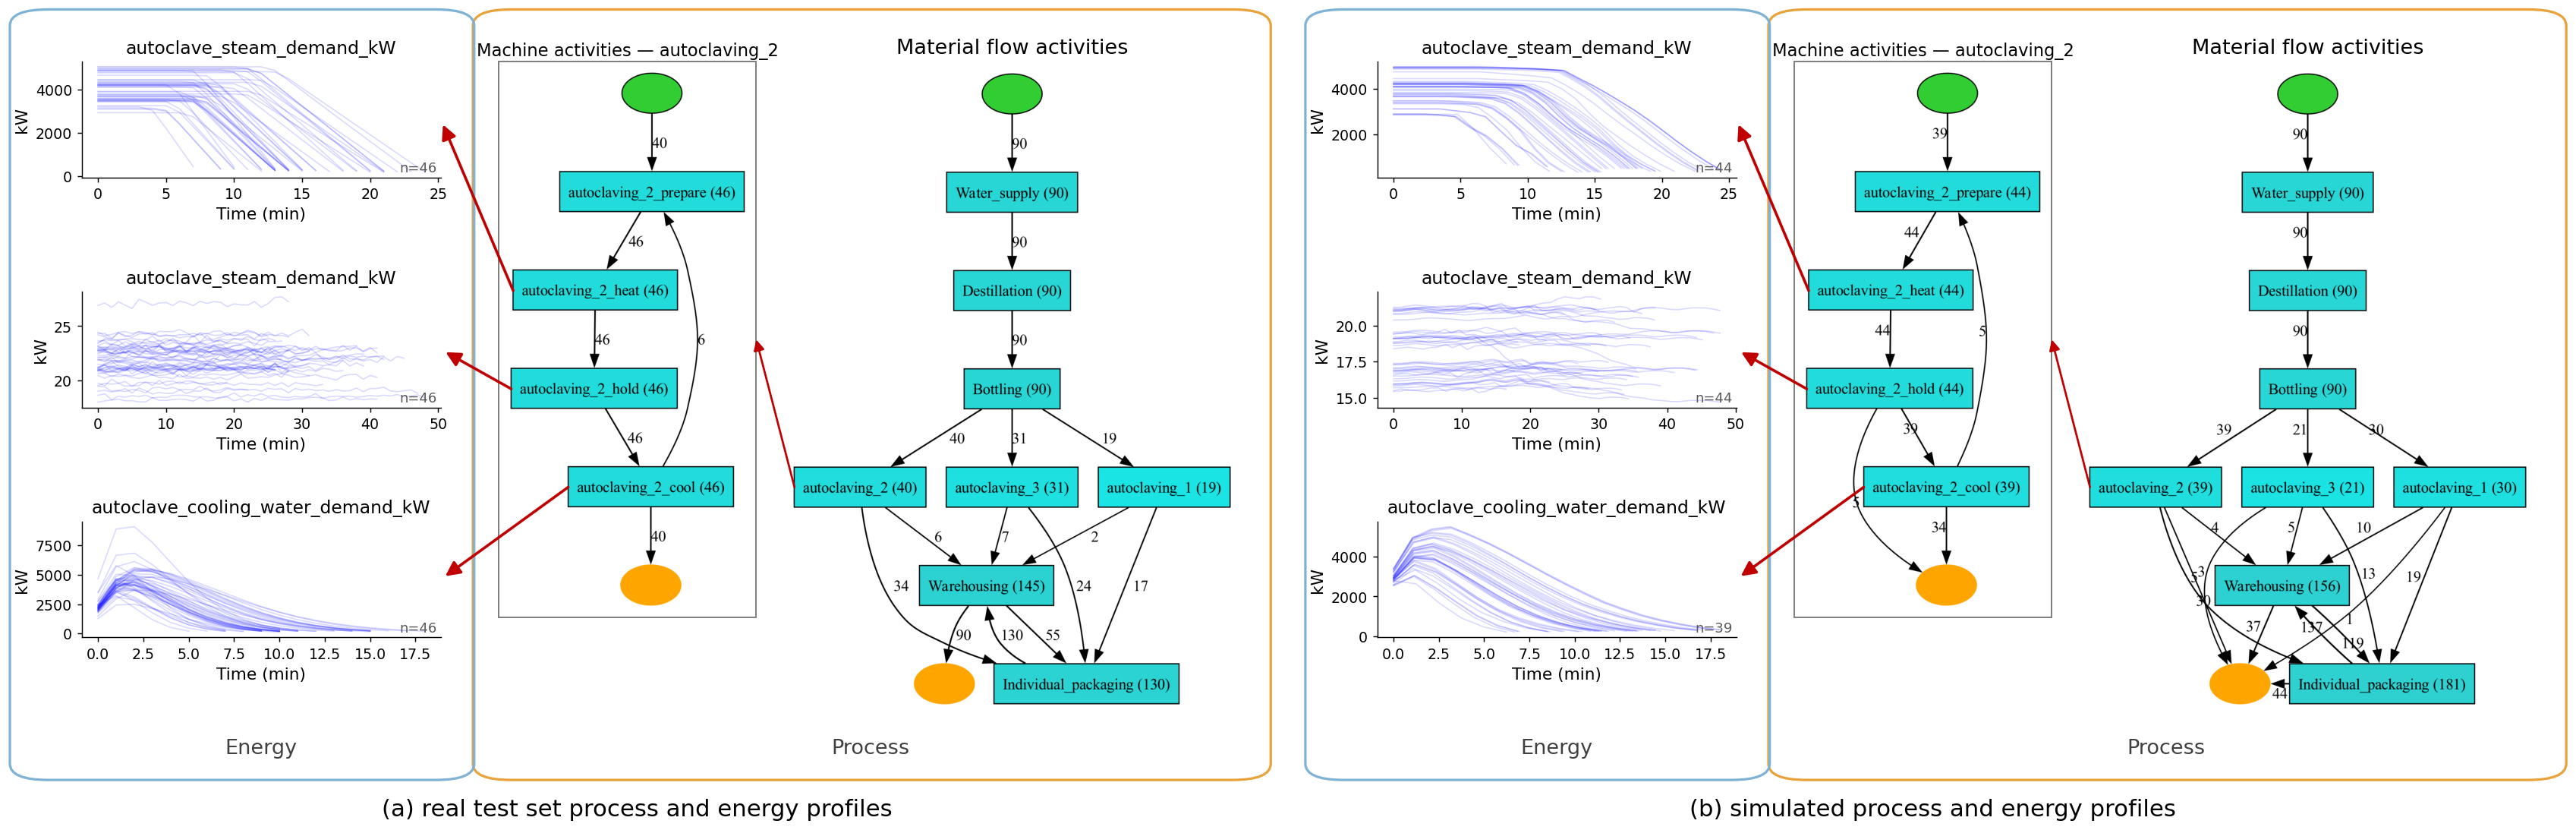

In [21]:
# ── Combined figure: (a) real | (b) simulated ────────────────────────────────
COMBINED_W, COMBINED_H = 26.0, 11.0  # inches; each block gets half the width
COMBINED_FS = 1.00                   # font scale inside a half-width block

# ONE plan for both halves -> same net scale, same panel width, so (a) and (b) are the same size
_plan = plan_blocks([BLOCK_REAL, BLOCK_SIM], COMBINED_W, COMBINED_H, rw=0.5, rh=1.0)
# Panel axes are NOT pinned across the halves: each panel autoscales on its own curves, so a
# profile is drawn at its own range instead of being squeezed into a shared one.
_lims = None

fig = plt.figure(figsize=(COMBINED_W, COMBINED_H))
draw_block(fig, (0.000, 0.0, 0.5, 1.0), BLOCK_REAL, CAPTION_REAL,
           COMBINED_W, COMBINED_H, _plan, fs=COMBINED_FS)
draw_block(fig, (0.505, 0.0, 0.5, 1.0), BLOCK_SIM, CAPTION_SIM,
           COMBINED_W, COMBINED_H, _plan, fs=COMBINED_FS)

if SAVE:
    _p = OUT / f'paper_figure_combined.pdf'
    fig.savefig(_p, format='pdf', bbox_inches='tight', pad_inches=0.15)
    print(f'saved {_p}')
plt.show()


---

## 11. The same figure for a second process and object — `process_2` / line `l01`

Same idea, different plant: the CIP/heating line `l01` of `process_2` instead of `autoclaving_2` of
`process_1`. Two things are different in the data and therefore in the figure:

* **One net instead of two.** `process_1` has a station→machine hierarchy (`Autoclaving` →
  `autoclaving_{1,2,3}`), so the right side carries a material-flow net plus a zoom into one machine.
  `process_2` has no such hierarchy in the run: the gold log holds two lines (`l01`, `l02`), but the
  pipeline only ever modelled `l01` — `predicted_logs/process_2_test_set.parquet` and every simulated
  log contain `l01` alone. So there is nothing to zoom into, and the right side is a single net: the
  activities of `l01`, mined from the real test log in (a) and from the simulated log in (b). The
  profile arrows start at those activity boxes directly.
* **Sensor names.** `process_1`'s gold `df_expanded` already carries `*_energy_to_model` columns;
  `process_2`'s carries `*_energy`, and only the run's curve files use the `_to_model` suffix. The
  panels below name the sensor once, without a suffix, and each side appends the one it needs.

Everything else — the test split, the per-occurrence curve extraction, `draw_block`, the shared
`plan_blocks` scale — is the code already used above. The net + curve counts inside each half again
come from one and the same log, so the box counts and the `n=` on the panels agree.

Curves shown: `Produktion`, `Warten auf Ziel` and `Grundstellung` — the three `l01` activities that are
long enough for the run's minute-resolution curves to hold more than a couple of samples (the short
ones, e.g. `Nachlauf` at ~20 s, exist in the real 5 s data but collapse to <3 points in the
simulated curves, so they would draw an empty panel in (b)).

In [22]:
# ── 11.1 config + data for the second process ────────────────────────────────
# Everything here is prefixed P2_/p2_ so section 11 cannot disturb the process_1 blocks that the
# figure above was built from -- they are already rendered, but the globals stay intact.
P2_PROCESS  = 'process_2'
P2_FOCUS    = 'l01'                  # the modelled line
P2_RUN      = 'experiment_988'   # 991 is process_1 only — the section-11 comparison process lives here
P2_SIM_MODE = 'petri_net_budget'     # lowest test_overall_error for process_2 (0.347;
                                     # the ml_plus variants land at 0.357 / 0.361)
P2_APPROACH = 'ml_step_dtw'           # NOT cell 1's approach: this block reads P2_RUN
                                     # (988), whose complete-curve stage only ever wrote
                                     # ml_step_dtw — asking it for _smooth asserts out

# (activity, sensor) without the suffix -- '<s>_energy' in the gold data, '<s>_energy_to_model'
# in the run's curve files.
P2_PANELS = [
    ('Produktion',      'pro_power_kW'),
    ('Warten auf Ziel', 'medium_power_kW'),
    ('Grundstellung',   'pro_power_kW'),
]

_p2_matches = [d for d in sorted(RESULTS.iterdir()) if d.is_dir() and (d.name == P2_RUN or P2_RUN in d.name)]
assert _p2_matches, f'no run under {RESULTS} matching {P2_RUN!r}'
p2_run_dir = _p2_matches[-1]

P2_GOLD = REPO / 'data' / 'gold' / f'experiment_{DATA_EXPERIMENT}' / P2_PROCESS / 'datasets'
p2_expanded = pd.read_parquet(P2_GOLD / 'df_expanded.parquet')

# case set = the run's own test split, exactly as in cell 1
p2_real_log = pd.read_parquet(p2_run_dir / 'predicted_logs' / f'{P2_PROCESS}_test_set.parquet')
p2_cases    = set(p2_real_log['case_id'].dropna().unique())
p2_real_log = (p2_real_log[p2_real_log['object'] == P2_FOCUS]
               .sort_values(['case_id', 'timestamp_start']).copy())

p2_sim_log = pd.read_parquet(p2_run_dir / 'predicted_logs' / f'{P2_PROCESS}_{P2_SIM_MODE}.parquet')
p2_sim_log = (p2_sim_log[p2_sim_log['case_id'].isin(p2_cases) & (p2_sim_log['object'] == P2_FOCUS)]
              .sort_values(['case_id', 'timestamp_start']).copy())
for _c in ('timestamp_start', 'timestamp_end'):
    p2_sim_log[_c] = pd.to_datetime(p2_sim_log[_c])

p2_curves_file = (p2_run_dir / 'complete_curve_eval_results' / P2_PROCESS / P2_SIM_MODE /
                  f'predicted_curves_{P2_APPROACH}.parquet')
assert p2_curves_file.exists(), f'{p2_curves_file} missing'
p2_curves_df = pd.read_parquet(p2_curves_file)

print(f'run    : {p2_run_dir.name}')
print(f'gold   : {P2_GOLD.relative_to(REPO)}')
print(f'cases  : {len(p2_cases)} test cases (objects in the run: '
      f'{sorted(pd.read_parquet(p2_run_dir / "predicted_logs" / f"{P2_PROCESS}_test_set.parquet")["object"].unique())})')
print(f'real   : {len(p2_real_log)} events on {P2_FOCUS}, '
      f'{p2_real_log["activity"].nunique()} activities')
print(f'sim    : {len(p2_sim_log)} events on {P2_FOCUS}, '
      f'{p2_sim_log["activity"].nunique()} activities  ({P2_SIM_MODE})')
print(f'curves : {p2_curves_file.relative_to(p2_run_dir)} | series '
      f'{sorted(p2_curves_df["series"].unique())}')
display(pd.DataFrame({
    'real': p2_real_log['activity'].value_counts(),
    'sim':  p2_sim_log['activity'].value_counts(),
}).fillna(0).astype(int).sort_values('real', ascending=False))

run    : experiment_988_20260728_163037
gold   : data/gold/experiment_1/process_2/datasets
cases  : 15 test cases (objects in the run: ['l01'])
real   : 416 events on l01, 12 activities
sim    : 395 events on l01, 12 activities  (petri_net_budget)
curves : complete_curve_eval_results/process_2/petri_net_budget/predicted_curves_ml_step_dtw.parquet | series ['predicted', 'real']


,real,sim
activity,,
Warten auf Ziel,91,84
Materialvalidierung,81,77
Nachlauf,81,76
Produktion,81,76
Grundstellung,12,10
Leitung zum HSM füllen,11,12
Leitung zum Vorheizer füllen,11,12
Spülen auf Gully,11,10
Spülen mit Wasser,11,7


In [23]:
# ── 11.2 curve extraction for process_2 ──────────────────────────────────────
# Same rule as sections 4 / 9: one curve per OCCURRENCE, on its own elapsed time, no resampling.
# Only the bookkeeping differs -- process_2's activity names do not carry the object, so the
# occurrence windows are taken from a log already filtered to P2_FOCUS.

def p2_curves_real(activity, sensor):
    """Real 5 s readings of the gold df_expanded, per occurrence of `activity` on P2_FOCUS."""
    # gold columns carry '_energy_to_model' since the process_2 regeneration;
    # older gold files used the bare '_energy' suffix — take whichever is present
    col = next(c for c in (f'{sensor}_energy_to_model', f'{sensor}_energy')
               if c in p2_expanded.columns)
    sub = p2_expanded[(p2_expanded['activity_log'] == activity)
                      & (p2_expanded['object_log'] == P2_FOCUS)
                      & (p2_expanded['case_id_log'].isin(p2_cases))].sort_values('datetime_energy')
    out = []
    for _, g in sub.groupby(['case_id_log', 'timestamp_start_log'], sort=True):
        v = g[col].to_numpy(dtype=float)
        t = (g['datetime_energy'] - g['datetime_energy'].iloc[0]).dt.total_seconds().to_numpy() / 60
        mask = np.isfinite(v)
        v, t = v[mask], t[mask]
        if len(v) > 2:
            out.append((t, v))
    return out


def p2_curves_run(activity, sensor, series='predicted'):
    """The run's saved curves, sliced by the occurrence windows of the simulated l01 log."""
    col = f'{sensor}_energy_to_model'
    dfc = p2_curves_df[(p2_curves_df['sensor'] == col) & (p2_curves_df['series'] == series)]
    assert not dfc.empty, (f'no curves for sensor {col!r} / series {series!r} — have '
                           f'{sorted(p2_curves_df["sensor"].unique())}')
    by_case = {c: g.sort_values('t_minutes') for c, g in dfc.groupby('case_id')}
    case_t0 = p2_sim_log.groupby('case_id')['timestamp_start'].min()

    out = []
    for _, r in p2_sim_log[p2_sim_log['activity'] == activity].iterrows():
        g = by_case.get(r['case_id'])
        if g is None:
            continue
        t0 = case_t0[r['case_id']]
        a = (r['timestamp_start'] - t0).total_seconds() / 60
        b = (r['timestamp_end']   - t0).total_seconds() / 60
        sel = g.loc[g['t_minutes'].between(a - _EPS_MIN, b + _EPS_MIN)]   # _EPS_MIN = 0, see cell 4
        v = sel['value'].to_numpy(dtype=float)
        t = sel['t_minutes'].to_numpy(dtype=float) - a
        mask = np.isfinite(v)
        v, t = v[mask], t[mask]
        if len(v) > 2:
            out.append((t, v))
    return out


def p2_panel_data(getter):
    """panel_data dict in the shape draw_block expects, keyed by (activity, sensor column)."""
    out = {}
    for activity, sensor in P2_PANELS:
        curves = getter(activity, sensor)
        if len(curves) < 2:
            print(f'!! {activity} / {sensor}: only {len(curves)} curve(s) — panel dropped')
            continue
        n_total = len(curves)
        used = curves[:MAX_CURVES] if MAX_CURVES else curves
        ylabel, title = panel_meta(sensor)
        out[(activity, sensor)] = dict(curves=used, n_total=n_total, ylabel=ylabel, title=title)
        print(f'  {activity:<20} {sensor:<18} n={len(used)}'
              + ('' if len(used) == n_total else f' of {n_total}'))
    return out


print('real (gold expanded, 5 s):')
p2_pd_real = p2_panel_data(p2_curves_real)
print(f'simulated ({P2_SIM_MODE} / {P2_APPROACH}):')
p2_pd_sim  = p2_panel_data(p2_curves_run)

real (gold expanded, 5 s):
  Produktion           pro_power_kW       n=60 of 81
  Warten auf Ziel      medium_power_kW    n=60 of 90


  Grundstellung        pro_power_kW       n=12
simulated (petri_net_budget / ml_step_dtw):
  Produktion           pro_power_kW       n=60 of 76
  Warten auf Ziel      medium_power_kW    n=60 of 84


  Grundstellung        pro_power_kW       n=10


In [24]:
# ── 11.3 the two nets and the two single-net blocks ──────────────────────────
# (a) is mined from the real test log, (b) from the simulated log of the same run -- so each half's
# box counts and panel n= come from one file, as in section 9.
p2_png_real, p2_gviz_real = heuristic_net(p2_real_log, 'activity',
                                          f'net_{P2_PROCESS}_{P2_FOCUS}_{SPLIT}_real.pdf')
p2_png_sim,  p2_gviz_sim  = heuristic_net(p2_sim_log,  'activity',
                                          f'net_{P2_PROCESS}_{P2_FOCUS}_{SPLIT}_sim.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=p2_png_real)); display(Image(filename=p2_png_sim))

# png_machine=None -> single-net block: the arrows leave the process net's own activity boxes
P2_BLOCK_REAL = make_block(p2_png_real, p2_gviz_real, None, None, p2_pd_real, P2_FOCUS,
                           net_title=f'Process activities — {P2_FOCUS}')
P2_BLOCK_SIM  = make_block(p2_png_sim,  p2_gviz_sim,  None, None, p2_pd_sim,  P2_FOCUS,
                           net_title=f'Process activities — {P2_FOCUS}')
print(f'{P2_PROCESS} / {P2_FOCUS}: both blocks ready')

process_2 / l01: both blocks ready


saved visuals/process_and_profiles/paper_figure_combined_process_2_l01.pdf


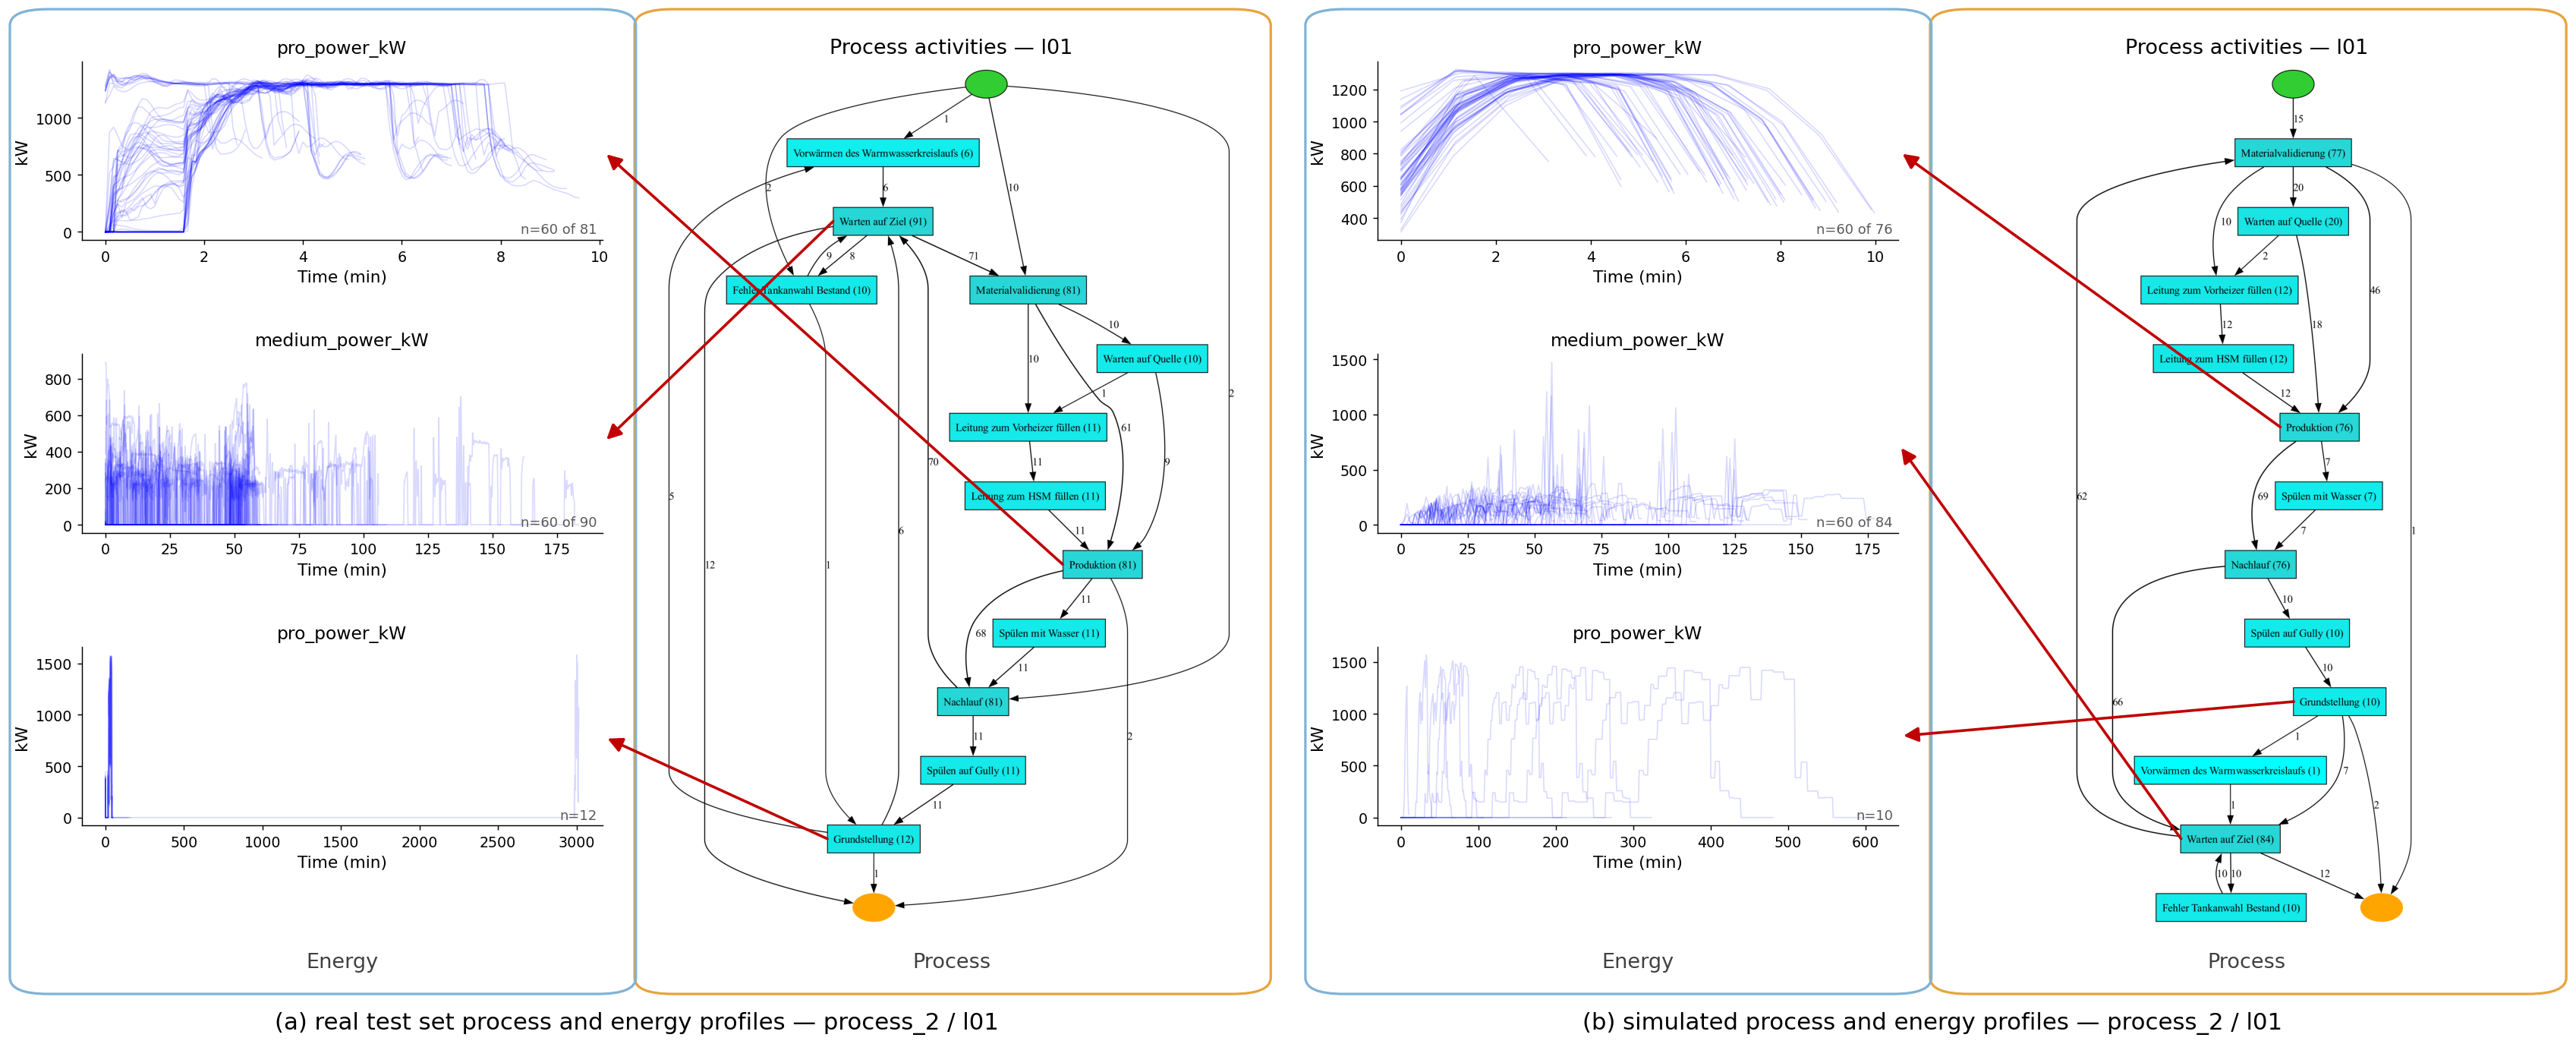

In [25]:
# ── 11.4 combined figure for process_2 / l01: (a) real | (b) simulated ───────
P2_CAPTION_REAL = f'(a) real test set process and energy profiles — {P2_PROCESS} / {P2_FOCUS}'
P2_CAPTION_SIM  = f'(b) simulated process and energy profiles — {P2_PROCESS} / {P2_FOCUS}'

_p2_plan = plan_blocks([P2_BLOCK_REAL, P2_BLOCK_SIM], COMBINED_W, COMBINED_H, rw=0.5, rh=1.0)
# no shared panel limits — each profile keeps its own autoscaled axes (see 10)

fig = plt.figure(figsize=(COMBINED_W, COMBINED_H))
draw_block(fig, (0.000, 0.0, 0.5, 1.0), P2_BLOCK_REAL, P2_CAPTION_REAL,
           COMBINED_W, COMBINED_H, _p2_plan, fs=COMBINED_FS)
draw_block(fig, (0.505, 0.0, 0.5, 1.0), P2_BLOCK_SIM, P2_CAPTION_SIM,
           COMBINED_W, COMBINED_H, _p2_plan, fs=COMBINED_FS)

if SAVE:
    _p = OUT / f'paper_figure_combined_{P2_PROCESS}_{P2_FOCUS}.pdf'
    fig.savefig(_p, format='pdf', bbox_inches='tight', pad_inches=0.15)
    print(f'saved {_p}')
plt.show()